# Лабораторная работа 2
## Временные ряды: прогноз температуры на 1 неделю вперёд

In [41]:
from openpyxl import load_workbook
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (r2_score, mean_absolute_error,
                             mean_absolute_percentage_error,
                             mean_squared_error, root_mean_squared_error,
                             median_absolute_error)
from xgboost import XGBRegressor
from mpl_toolkits.axes_grid1 import make_axes_locatable
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pywt

## 1. Все листы Excel
В файле 8 листов, но реальные данные только в трёх (два скрыты) Имена листов записаны в cp1251, прочитанной как latin1 — починим

In [42]:
file = 'have_fun.xlsx'


def fix_encoding(s):
    if isinstance(s, str):
        try:
            return s.encode('latin1').decode('cp1251')
        except Exception:
            return s
    return s


wb = load_workbook(file, data_only=True)
for ws in wb.worksheets:
    print(f'{fix_encoding(ws.title):40s}  state={ws.sheet_state}')

Лист1                                     state=visible
Лист1                                     state=visible
МАИ                                       state=visible
это                                       state=visible
я                                         state=visible
!                                         state=visible
Лист2_строковые_NaN_выбросы               state=hidden
Лист3_смешанные_типы                      state=hidden


In [43]:
raw = pd.read_excel(file, sheet_name=None, engine='openpyxl')

sheets = {}
for name, d in raw.items():
    d = d.copy()
    d.columns = [fix_encoding(col) for col in d.columns]
    d = d.map(fix_encoding)

    if 'ds' in d.columns and len(d) > 10:
        sheets[fix_encoding(name)] = d

for n, d in sheets.items():
    print(n, '->', d.shape)

Лист1 -> (125124, 10)
Лист2_строковые_NaN_выбросы -> (125169, 25)
Лист3_смешанные_типы -> (122736, 10)


In [44]:
# Что внутри каждого листа
for n, d in sheets.items():
    print(n)
    print(d.dtypes)
    print('пропусков:', d.isna().sum().sum())
    display(d.head())

Лист1
temperature_2m                 float64
relative_humidity_2m             int64
precipitation                  float64
rain                           float64
snowfall                       float64
weathercode                      int64
wind_speed_10m                 float64
surface_pressure               float64
ds                      datetime64[us]
city                               str
dtype: object
пропусков: 4374


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,3.800000,82,0.0,0.0,0.0,3,19.100000,1010.000000,2020-01-31 02:00:00,Геленджик
1,-3.000000,70,0.0,0.0,0.0,3,24.000000,981.900024,2025-02-28 09:00:00,Благовещенск
2,-1.300000,86,0.0,0.0,0.0,2,8.800000,1021.200012,2022-01-03 02:00:00,Геленджик
3,19.299999,49,0.0,0.0,0.0,0,22.799999,1016.200012,2020-09-17 06:00:00,Геленджик
4,9.600000,89,0.0,0.0,0.0,0,8.800000,1024.400024,2025-04-16 05:00:00,Геленджик


Лист2_строковые_NaN_выбросы
temperature_2m                  object
relative_humidity_2m           float64
precipitation                   object
rain                           float64
snowfall                       float64
weathercode                    float64
wind_speed_10m                  object
surface_pressure               float64
ds                      datetime64[us]
city                               str
Unnamed: 10                    float64
Unnamed: 11                        str
Unnamed: 12                        str
Unnamed: 13                        str
Unnamed: 14                     object
Unnamed: 15                     object
Unnamed: 16                     object
Unnamed: 17                     object
Unnamed: 18                     object
Unnamed: 19                     object
Unnamed: 20                     object
Unnamed: 21                     object
Unnamed: 22                     object
Unnamed: 23                     object
Unnamed: 24                        s

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,-6.5,92.0,0,0.0,0.0,3.0,10.8,1000.500000,2019-01-01 00:00:00,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-6.8,92.0,0,0.0,0.0,3.0,10.5,1000.299988,2019-01-01 01:00:00,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-6.8,92.0,0,0.0,0.0,3.0,10.8,1000.000000,2019-01-01 02:00:00,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-5.8,93.0,0,0.0,0.0,3.0,12.2,999.299988,2019-01-01 03:00:00,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,79.276929,93.0,0,0.0,0.0,3.0,14.4,998.599976,2019-01-01 04:00:00,Москва,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Лист3_смешанные_типы
temperature_2m                  object
relative_humidity_2m           float64
precipitation                   object
rain                           float64
snowfall                       float64
weathercode                     object
wind_speed_10m                  object
surface_pressure               float64
ds                      datetime64[us]
city                               str
dtype: object
пропусков: 259


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,-1.8,85.0,0,0.0,0.00,3,23.5,1015.200012,2019-01-01 00:00:00,Санкт-Петербург
1,-1.9,83.0,0,0.0,0.00,3,26,1013.200012,2019-01-01 01:00:00,Санкт-Петербург
2,-2,85.0,0,0.0,0.00,3,26.200001,1011.700012,2019-01-01 02:00:00,Санкт-Петербург
3,-2.3,86.0,0,0.0,0.00,3,26.9,1009.900024,2019-01-01 03:00:00,Санкт-Петербург
4,-2.3,86.0,0.2,0.0,0.14,71,27.9,1007.700012,2019-01-01 04:00:00,Санкт-Петербург


### Загружаем данные из нормализованного файла
Используем файл `have_fun_clear.xlsx`, из которого были удалены лишние листы и восстановлены смещенные столбцы


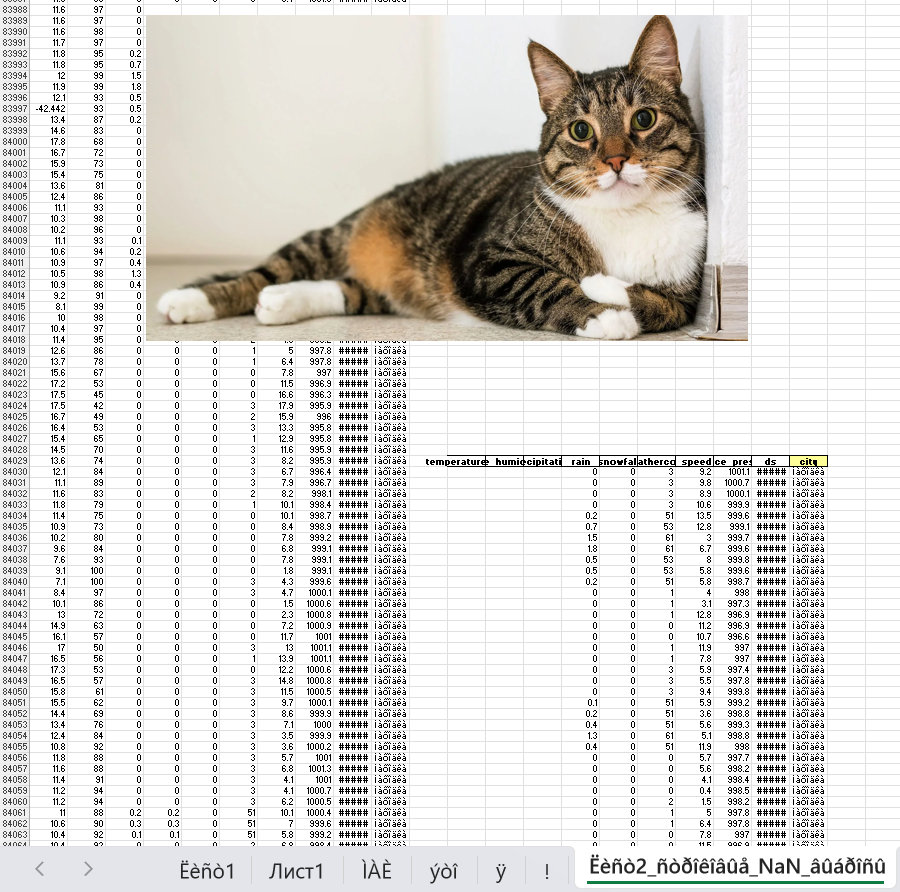

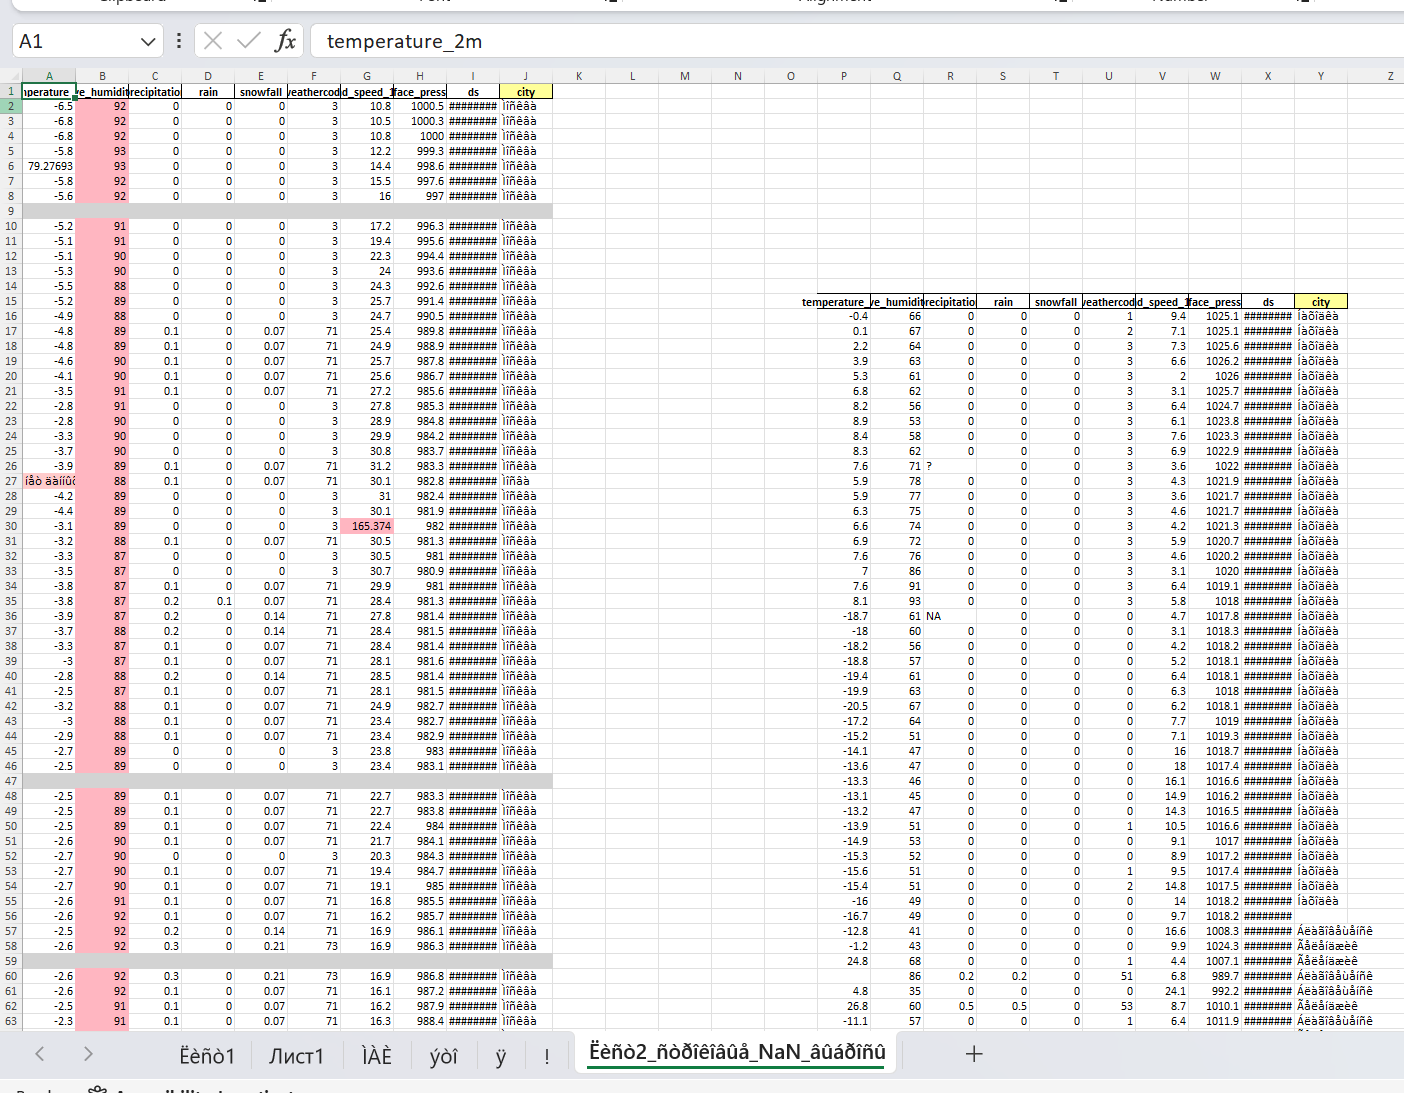

In [45]:
clean_file = 'have_fun_clear.xlsx'
expected_cols = [
    'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain',
    'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure',
    'ds', 'city'
]

raw_clean = pd.read_excel(clean_file, sheet_name=None, engine='openpyxl')

sheets = {}
for name, d in raw_clean.items():
    d = d.copy()
    d.columns = [fix_encoding(col) for col in d.columns]
    d = d.map(fix_encoding)

    if set(expected_cols).issubset(d.columns) and len(d) > 10:
        d = d[expected_cols].copy()
        sheets[fix_encoding(name)] = d

for n, d in sheets.items():
    print(n, '->', d.shape)
    display(d.head())


Лист1 -> (125124, 10)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,3.800000,82,0.0,0.0,0.0,3,19.100000,1010.000000,2020-01-31 02:00:00,Геленджик
1,-3.000000,70,0.0,0.0,0.0,3,24.000000,981.900024,2025-02-28 09:00:00,Благовещенск
2,-1.300000,86,0.0,0.0,0.0,2,8.800000,1021.200012,2022-01-03 02:00:00,Геленджик
3,19.299999,49,0.0,0.0,0.0,0,22.799999,1016.200012,2020-09-17 06:00:00,Геленджик
4,9.600000,89,0.0,0.0,0.0,0,8.800000,1024.400024,2025-04-16 05:00:00,Геленджик


Лист2_строковые_NaN_выбросы -> (125276, 10)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,-6.5,92.0,0,0.0,0.0,3.0,10.8,1000.500000,2019-01-01 00:00:00,Москва
1,-6.8,92.0,0,0.0,0.0,3.0,10.5,1000.299988,2019-01-01 01:00:00,Москва
2,-6.8,92.0,0,0.0,0.0,3.0,10.8,1000.000000,2019-01-01 02:00:00,Москва
3,-5.8,93.0,0,0.0,0.0,3.0,12.2,999.299988,2019-01-01 03:00:00,Москва
4,79.276929,93.0,0,0.0,0.0,3.0,14.4,998.599976,2019-01-01 04:00:00,Москва


Лист3_смешанные_типы -> (122736, 10)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,-1.8,85.0,0,0.0,0.00,3,23.5,1015.200012,2019-01-01 00:00:00,Санкт-Петербург
1,-1.9,83.0,0,0.0,0.00,3,26,1013.200012,2019-01-01 01:00:00,Санкт-Петербург
2,-2,85.0,0,0.0,0.00,3,26.200001,1011.700012,2019-01-01 02:00:00,Санкт-Петербург
3,-2.3,86.0,0,0.0,0.00,3,26.9,1009.900024,2019-01-01 03:00:00,Санкт-Петербург
4,-2.3,86.0,0.2,0.0,0.14,71,27.9,1007.700012,2019-01-01 04:00:00,Санкт-Петербург


## 2. Очистка и объединение

In [46]:
# Соединяем все листы в один датафрейм
df = pd.concat(list(sheets.values()), ignore_index=True)

df = df.drop(columns=[c for c in df.columns if str(c).startswith('Unnamed')])
df = df.dropna(how='all').dropna(axis=1, how='all')

print('размер:', df.shape)
df.info()

размер: (370682, 10)
<class 'pandas.DataFrame'>
Index: 370682 entries, 0 to 373135
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        368122 non-null  object        
 1   relative_humidity_2m  370677 non-null  float64       
 2   precipitation         368497 non-null  object        
 3   rain                  370682 non-null  float64       
 4   snowfall              370682 non-null  float64       
 5   weathercode           370681 non-null  object        
 6   wind_speed_10m        369080 non-null  object        
 7   surface_pressure      370681 non-null  float64       
 8   ds                    370680 non-null  datetime64[us]
 9   city                  370678 non-null  str           
dtypes: datetime64[us](1), float64(4), object(4), str(1)
memory usage: 31.1+ MB


### Найдём странные значения в числовых столбцах
Сначала смотрим, что вообще встречается, и только потом решаем что с этим делать

In [47]:
num_cols = [c for c in df.columns if c not in ['ds', 'city']]
found = {}

for col in num_cols:
    strange = set(v for v in df[col] if isinstance(v, str))
    if strange:
        found[col] = strange
        print(col, '->', strange)

temperature_2m -> {'нет данных', 'NAN', 'жарко', 'холодно', '---', '?', 'нормально'}
precipitation -> {'нет данных', 'NAN', 'ливень', 'сухо', 'морось', '---', '?'}
weathercode -> {'солнечно', 'дождь', 'пасмурно', 'снег'}
wind_speed_10m -> {'нет данных', 'NAN', 'шторм', 'туман', 'ветрено', 'гроза', '---', '?', 'тихо'}


## Чистим данные и нормализуем типы

In [48]:
if 'num_cols' not in globals():
    num_cols = [c for c in df.columns if c not in ['ds', 'city']]

non_numeric_report = []

for col in num_cols:
    original = df[col]
    normalized = (
        original
        .astype('string')
        .str.strip()
        .str.replace(',', '.', regex=False)
    )
    parsed = pd.to_numeric(normalized, errors='coerce')

    bad_values = sorted(normalized[original.notna() & parsed.isna()].dropna().unique())
    if bad_values:
        non_numeric_report.append({
            'column': col,
            'bad_values': bad_values,
            'count': int((original.notna() & parsed.isna()).sum()),
        })

    df[col] = parsed

df['ds'] = pd.to_datetime(df['ds'], errors='coerce').dt.floor('h')
df = df.sort_values(['city', 'ds'])

df['weathercode'] = (
    df.groupby('city')['weathercode']
    .transform(lambda s: s.ffill())
    .round()
    .astype('Int64')
)

display(pd.DataFrame(non_numeric_report))
df.info()

,column,bad_values,count
0,temperature_2m,"[---, ?, NAN, жарко, нет данных, нормально, хо...",1765
1,precipitation,"[---, ?, NAN, ливень, морось, нет данных, сухо]",1521
2,weathercode,"[дождь, пасмурно, снег, солнечно]",1841
3,wind_speed_10m,"[---, ?, NAN, ветрено, гроза, нет данных, тихо...",1487


<class 'pandas.DataFrame'>
Index: 370682 entries, 33772 to 151287
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        366357 non-null  Float64       
 1   relative_humidity_2m  370677 non-null  Float64       
 2   precipitation         366976 non-null  Float64       
 3   rain                  370682 non-null  Float64       
 4   snowfall              370682 non-null  Float64       
 5   weathercode           370678 non-null  Int64         
 6   wind_speed_10m        367593 non-null  Float64       
 7   surface_pressure      370681 non-null  Float64       
 8   ds                    370680 non-null  datetime64[us]
 9   city                  370678 non-null  str           
dtypes: Float64(7), Int64(1), datetime64[us](1), str(1)
memory usage: 33.9 MB


### Чистим города

In [49]:
def normalize_city_raw(name):
    name = fix_encoding(name)
    if pd.isna(name):
        return np.nan
    text = str(name).strip().replace('ё', 'е').replace('Ё', 'Е')
    return text.capitalize()


df['city'] = df['city'].apply(normalize_city_raw)
print('before:', sorted(df['city'].dropna().unique()))

city_fix = {
    'Москва': [
        'Москва', 'Мосва'
    ],
    'Санкт-Петербург': [
        'Санкт-петербург'
    ],
    'Сочи': [
        'Сочи', 'Сычи', 'Счи', 'Соч'
    ],
    'Находка': [
        'Находка'
    ],
    'Благовещенск': [
        'Благовещенск',
        'Благовещенскк',
        'Благовещенс'
    ],
    'Геленджик': [
        'Геленджик',
        'Геленджикк',
        'Геленджи'
    ],
}


def to_normal(name):
    for good, bad in city_fix.items():
        if name in bad:
            return good
    return np.nan


df['city'] = df['city'].apply(to_normal)
print('after:', sorted(df['city'].dropna().unique()))
print('missing city:', df['city'].isna().sum())


before: ['Благовещенс', 'Благовещенск', 'Благовещенскк', 'Геленджи', 'Геленджик', 'Геленджикк', 'Мосва', 'Москва', 'Находка', 'Санкт-петербург', 'Соч', 'Сочи', 'Счи', 'Сычи']
after: ['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
missing city: 4


In [50]:
# Выкидываем строки без города/даты и дубликаты
df = df.dropna(subset=['city', 'ds']).drop_duplicates()
print('размер:', df.shape)

размер: (368203, 10)


### Ручная очистка всего датасета
Сначала применяем одинаковые физические границы ко всему датасету Невозможные значения переводим в `NaN`, потом заполняем их внутри временного ряда каждого города


In [51]:
manual_bounds = {
    'temperature_2m': (-50, 50),
    'relative_humidity_2m': (0, 100),
    'precipitation': (0, 50),
    'rain': (0, 50),
    'snowfall': (0, 20),
    'weathercode': (0, 99),
    'wind_speed_10m': (0, 60),
    'surface_pressure': (950, 1050),
}

manual_clean_report = []
for col, (lo, hi) in manual_bounds.items():
    if col not in df.columns:
        continue
    bad = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
    manual_clean_report.append({'column': col, 'bad_values': int(bad.sum()), 'lo': lo, 'hi': hi})
    df.loc[bad, col] = np.nan

pd.DataFrame(manual_clean_report)


,column,bad_values,lo,hi
0,temperature_2m,627,-50,50
1,relative_humidity_2m,0,0,100
2,precipitation,613,0,50
3,rain,0,0,50
4,snowfall,0,0,20
5,weathercode,0,0,99
6,wind_speed_10m,613,0,60
7,surface_pressure,497,950,1050


### Часовая сетка и заполнение пропусков


In [52]:
# Если на одну (ds, city) попало несколько строк - усредним
df = df.groupby(['ds', 'city'], as_index=False).mean(numeric_only=True)

# Делаем сплошную часовую сетку для каждого города
parts = []
for city, sub in df.groupby('city'):
    sub = sub.set_index('ds').sort_index()
    idx = pd.date_range(sub.index.min(), sub.index.max(), freq='h')
    sub = sub.reindex(idx)
    sub['city'] = city
    sub.index.name = 'ds'
    parts.append(sub.reset_index())
df = pd.concat(parts, ignore_index=True)

print('пропусков до интерполяции:')
print(df.isna().sum())

пропусков до интерполяции:
ds                         0
city                       0
temperature_2m          4921
relative_humidity_2m       9
precipitation           4300
rain                       4
snowfall                   4
weathercode                4
wind_speed_10m          3681
surface_pressure         501
dtype: int64


### Заполняем пропуски и чистим по квартилям без утечки
После ручной очистки пропуски заполняются только `ffill` внутри каждого города Затем данные делятся по времени на train val test IQR-границы считаются только на train и применяются ко всем частям


In [53]:
# Заполняем пропуски внутри каждого города только прошлыми значениями
num_cols = [c for c in df.columns if c not in ['ds', 'city']]
filled = []
for city, sub in df.groupby('city'):
    sub = sub.sort_values('ds').copy()
    sub[num_cols] = sub[num_cols].ffill()
    filled.append(sub)
df = pd.concat(filled, ignore_index=True)

# Делим по времени до IQR, чтобы границы считались только на train
clean_horizon = globals().get('HORIZON', 168)
dates_clean = np.sort(df['ds'].dropna().unique())
val_start_clean = dates_clean[-clean_horizon * 4]
test_start_clean = dates_clean[-clean_horizon * 2]

split_masks = {
    'train': df['ds'] < val_start_clean,
    'val': (df['ds'] >= val_start_clean) & (df['ds'] < test_start_clean),
    'test': df['ds'] >= test_start_clean,
}

# precipitation rain snowfall и weathercode пропускаем, потому что там много реальных нулей и дискретных кодов
iqr_cols = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'surface_pressure']
iqr_report = []
for city in sorted(df['city'].dropna().unique()):
    city_mask = df['city'] == city
    train_city_mask = city_mask & split_masks['train']
    for col in iqr_cols:
        q1, q3 = df.loc[train_city_mask, col].quantile([0.25, 0.75])
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            continue

        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        before = df.loc[city_mask, col].copy()
        outlier_mask = (before < lo) | (before > hi)
        df.loc[city_mask, col] = before.clip(lo, hi)
        iqr_report.append({
            'city': city,
            'column': col,
            'lo': round(lo, 3),
            'hi': round(hi, 3),
            'changed_train': int(outlier_mask[split_masks['train'].loc[before.index]].sum()),
            'changed_val': int(outlier_mask[split_masks['val'].loc[before.index]].sum()),
            'changed_test': int(outlier_mask[split_masks['test'].loc[before.index]].sum()),
            'changed_total': int(outlier_mask.sum())
        })

print('Границы IQR считались только на train:')
print('train до', val_start_clean, 'val до', test_start_clean, 'test с', test_start_clean)
print('Пропуски после ffill и IQR:')
print(df.isna().sum())
display(pd.DataFrame(iqr_report).sort_values(['city', 'column']))
df.groupby('city')['temperature_2m'].describe().round(2)


Missing values after filling and IQR cleaning:
ds                      0
city                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
dtype: int64


,city,column,lo,hi,changed
1,Благовещенск,relative_humidity_2m,11.00,123.00,0
3,Благовещенск,surface_pressure,969.10,1023.50,68
0,Благовещенск,temperature_2m,-53.70,58.30,0
2,Благовещенск,wind_speed_10m,-3.00,22.60,1653
5,Геленджик,relative_humidity_2m,28.00,124.00,445
7,Геленджик,surface_pressure,997.35,1032.95,186
4,Геленджик,temperature_2m,-11.55,40.85,0
6,Геленджик,wind_speed_10m,-10.15,36.65,777
9,Москва,relative_humidity_2m,29.00,125.00,343
11,Москва,surface_pressure,967.00,1016.60,1397


,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Благовещенск,61368.0,2.21,15.98,-41.9,-11.7,3.5,16.3,35.0
Геленджик,61368.0,14.36,8.53,-10.0,8.1,13.8,21.2,37.8
Москва,61368.0,6.67,10.79,-25.45,-1.0,6.4,15.3,34.8
Находка,61367.0,6.8,11.88,-31.75,-2.5,7.8,17.0,33.2
Санкт-Петербург,61368.0,6.8,9.6,-21.65,0.1,5.9,14.6,35.7
Сочи,61368.0,15.04,7.46,-9.1,9.2,14.7,21.4,35.3


### Графики после разделения по городам


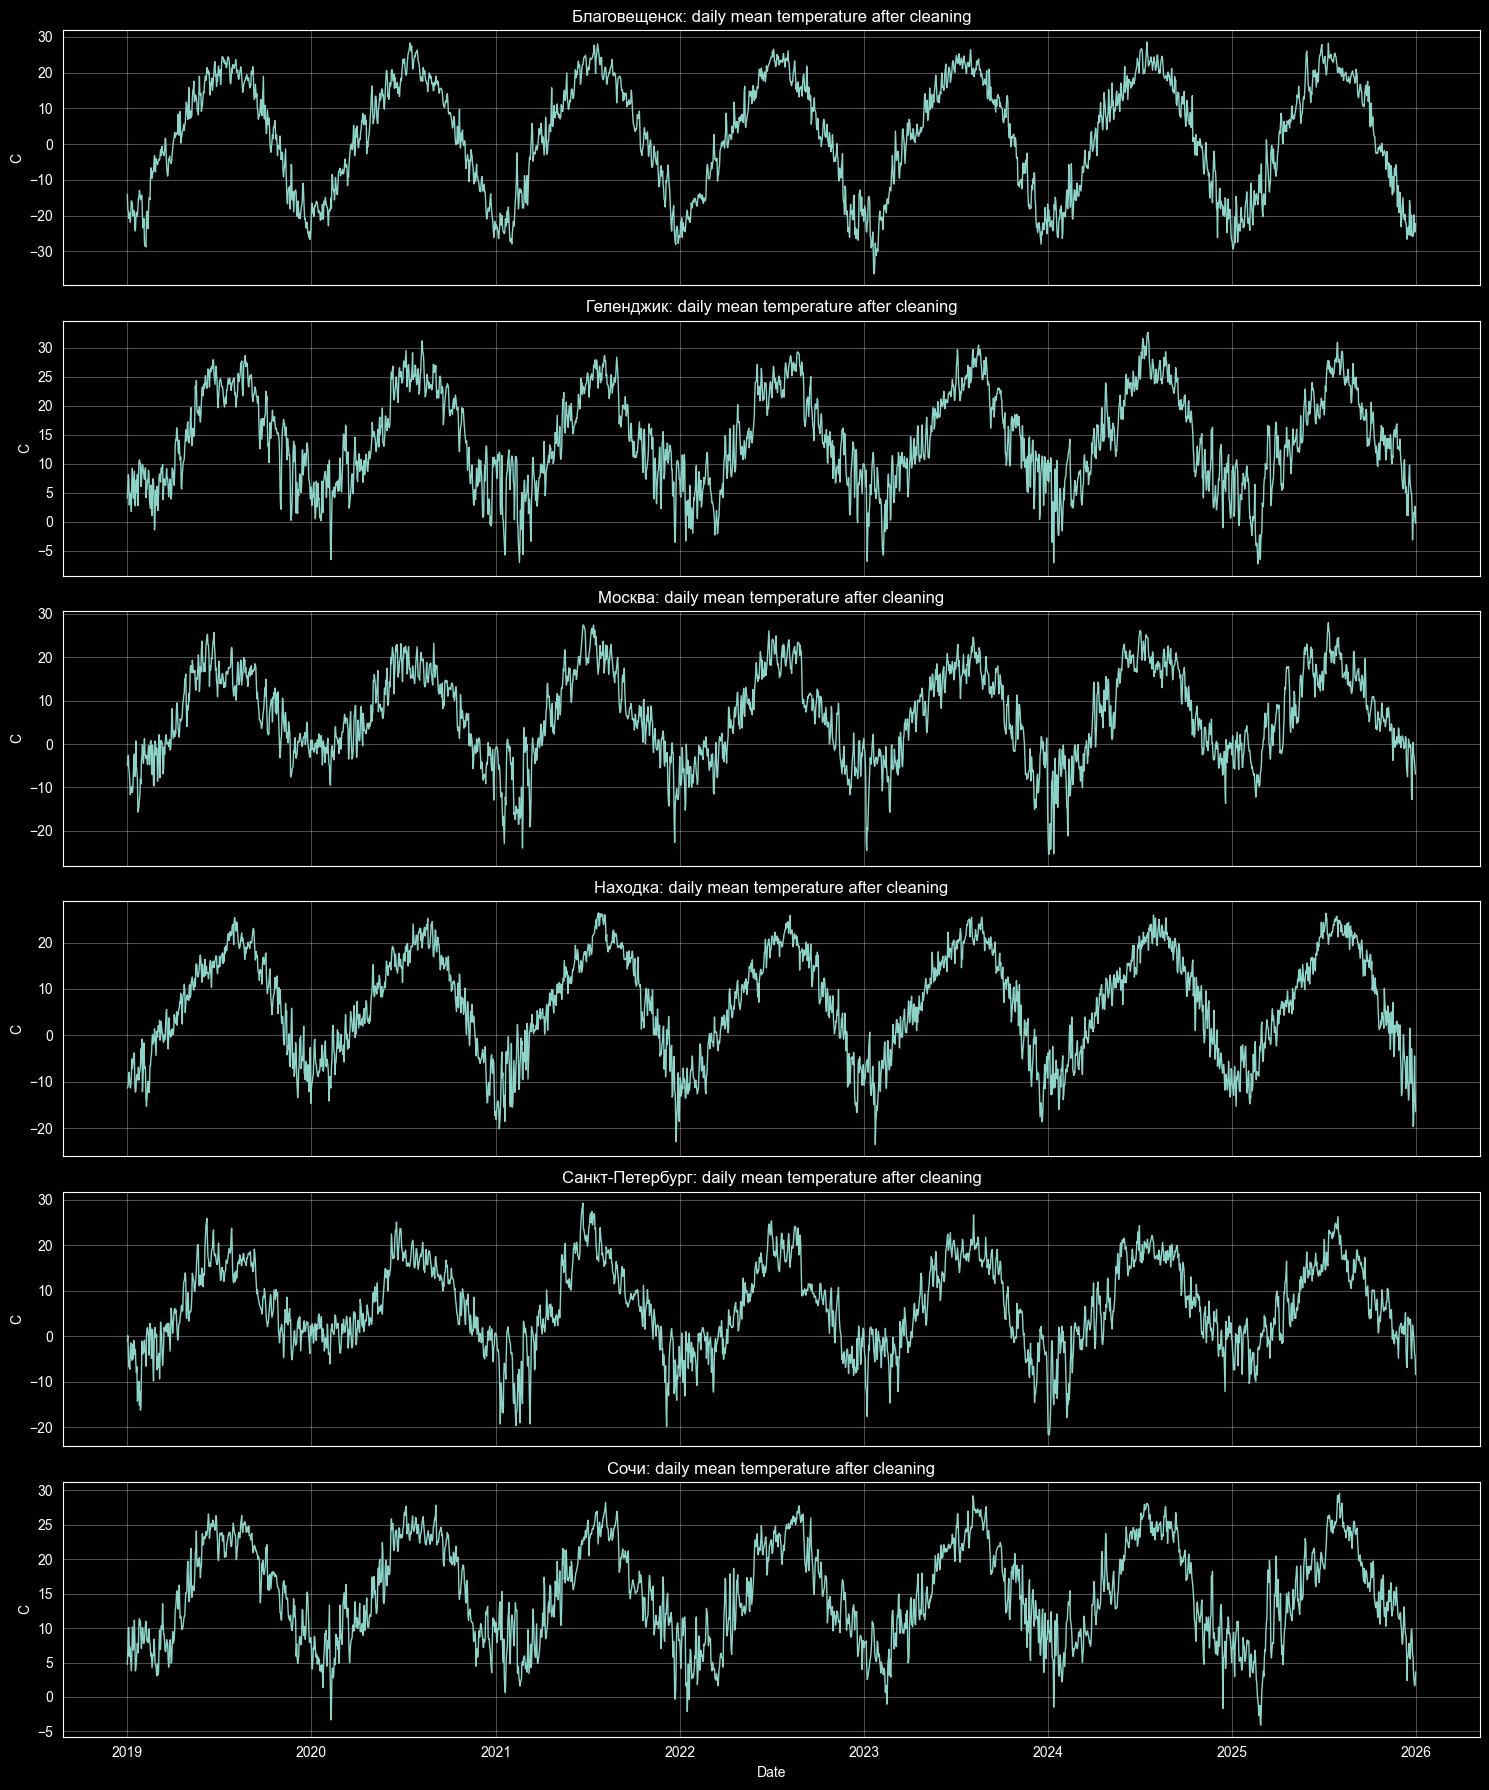

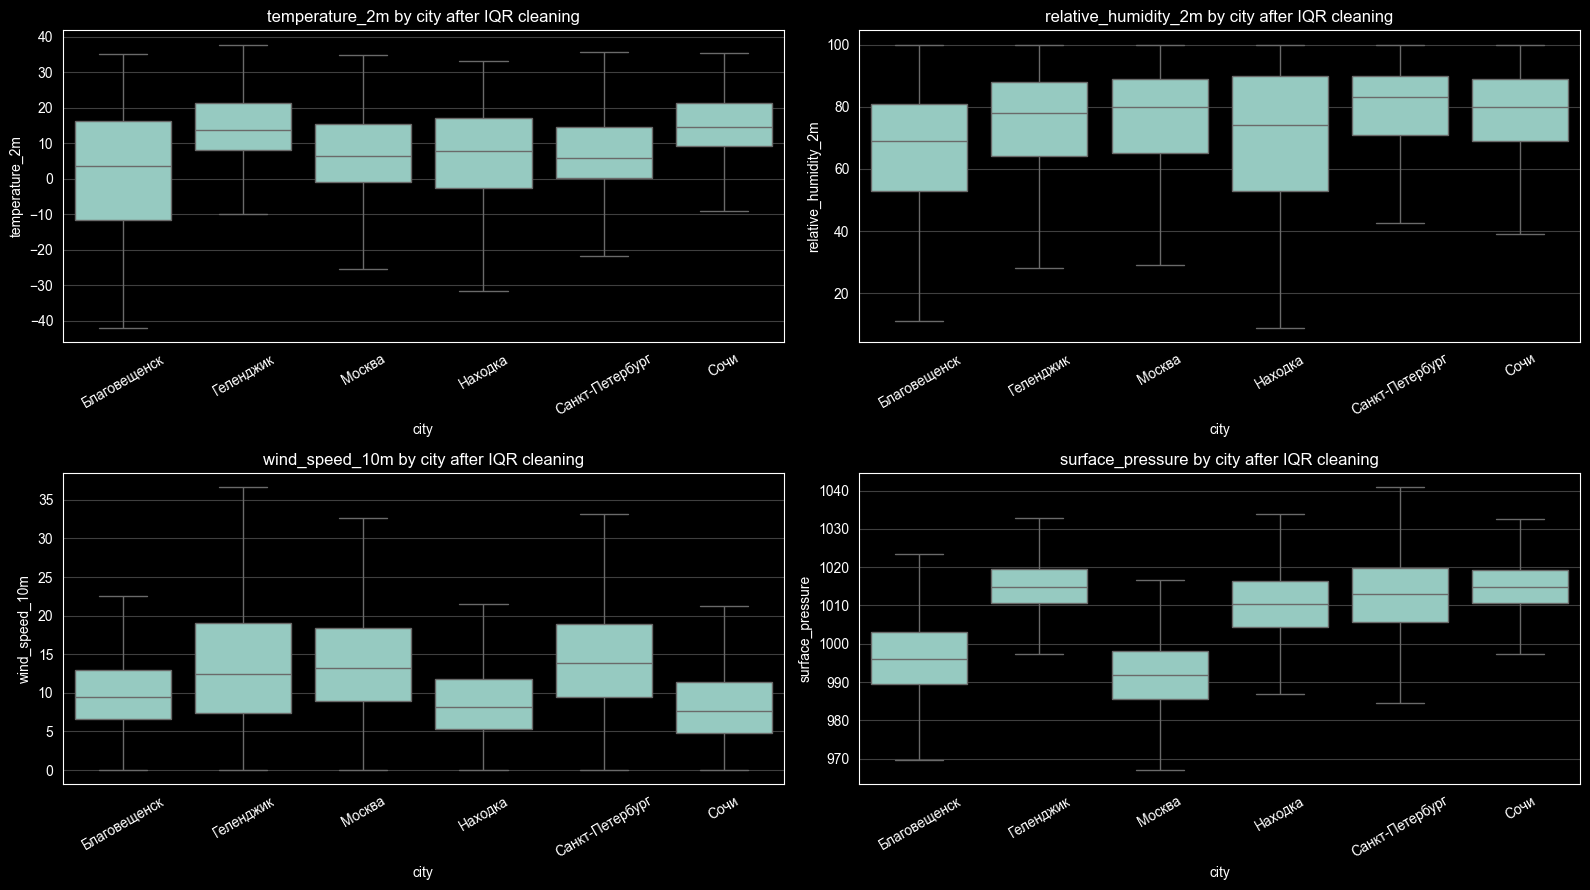

In [54]:
cities = sorted(df['city'].dropna().unique())
fig, axes = plt.subplots(len(cities), 1, figsize=(15, 3 * len(cities)), sharex=True)
if len(cities) == 1:
    axes = [axes]

for ax, city in zip(axes, cities):
    sub = df[df['city'] == city].sort_values('ds')
    daily = sub.set_index('ds')['temperature_2m'].resample('D').mean()
    ax.plot(daily.index, daily.values, linewidth=1)
    ax.set_title(f'{city}: daily mean temperature after cleaning')
    ax.set_ylabel('C')
    ax.grid(alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
plot_cols = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'surface_pressure']
for ax, col in zip(axes.ravel(), plot_cols):
    sns.boxplot(data=df, x='city', y=col, ax=ax)
    ax.set_title(f'{col} by city after IQR cleaning')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()


## 3. Анализ временного ряда

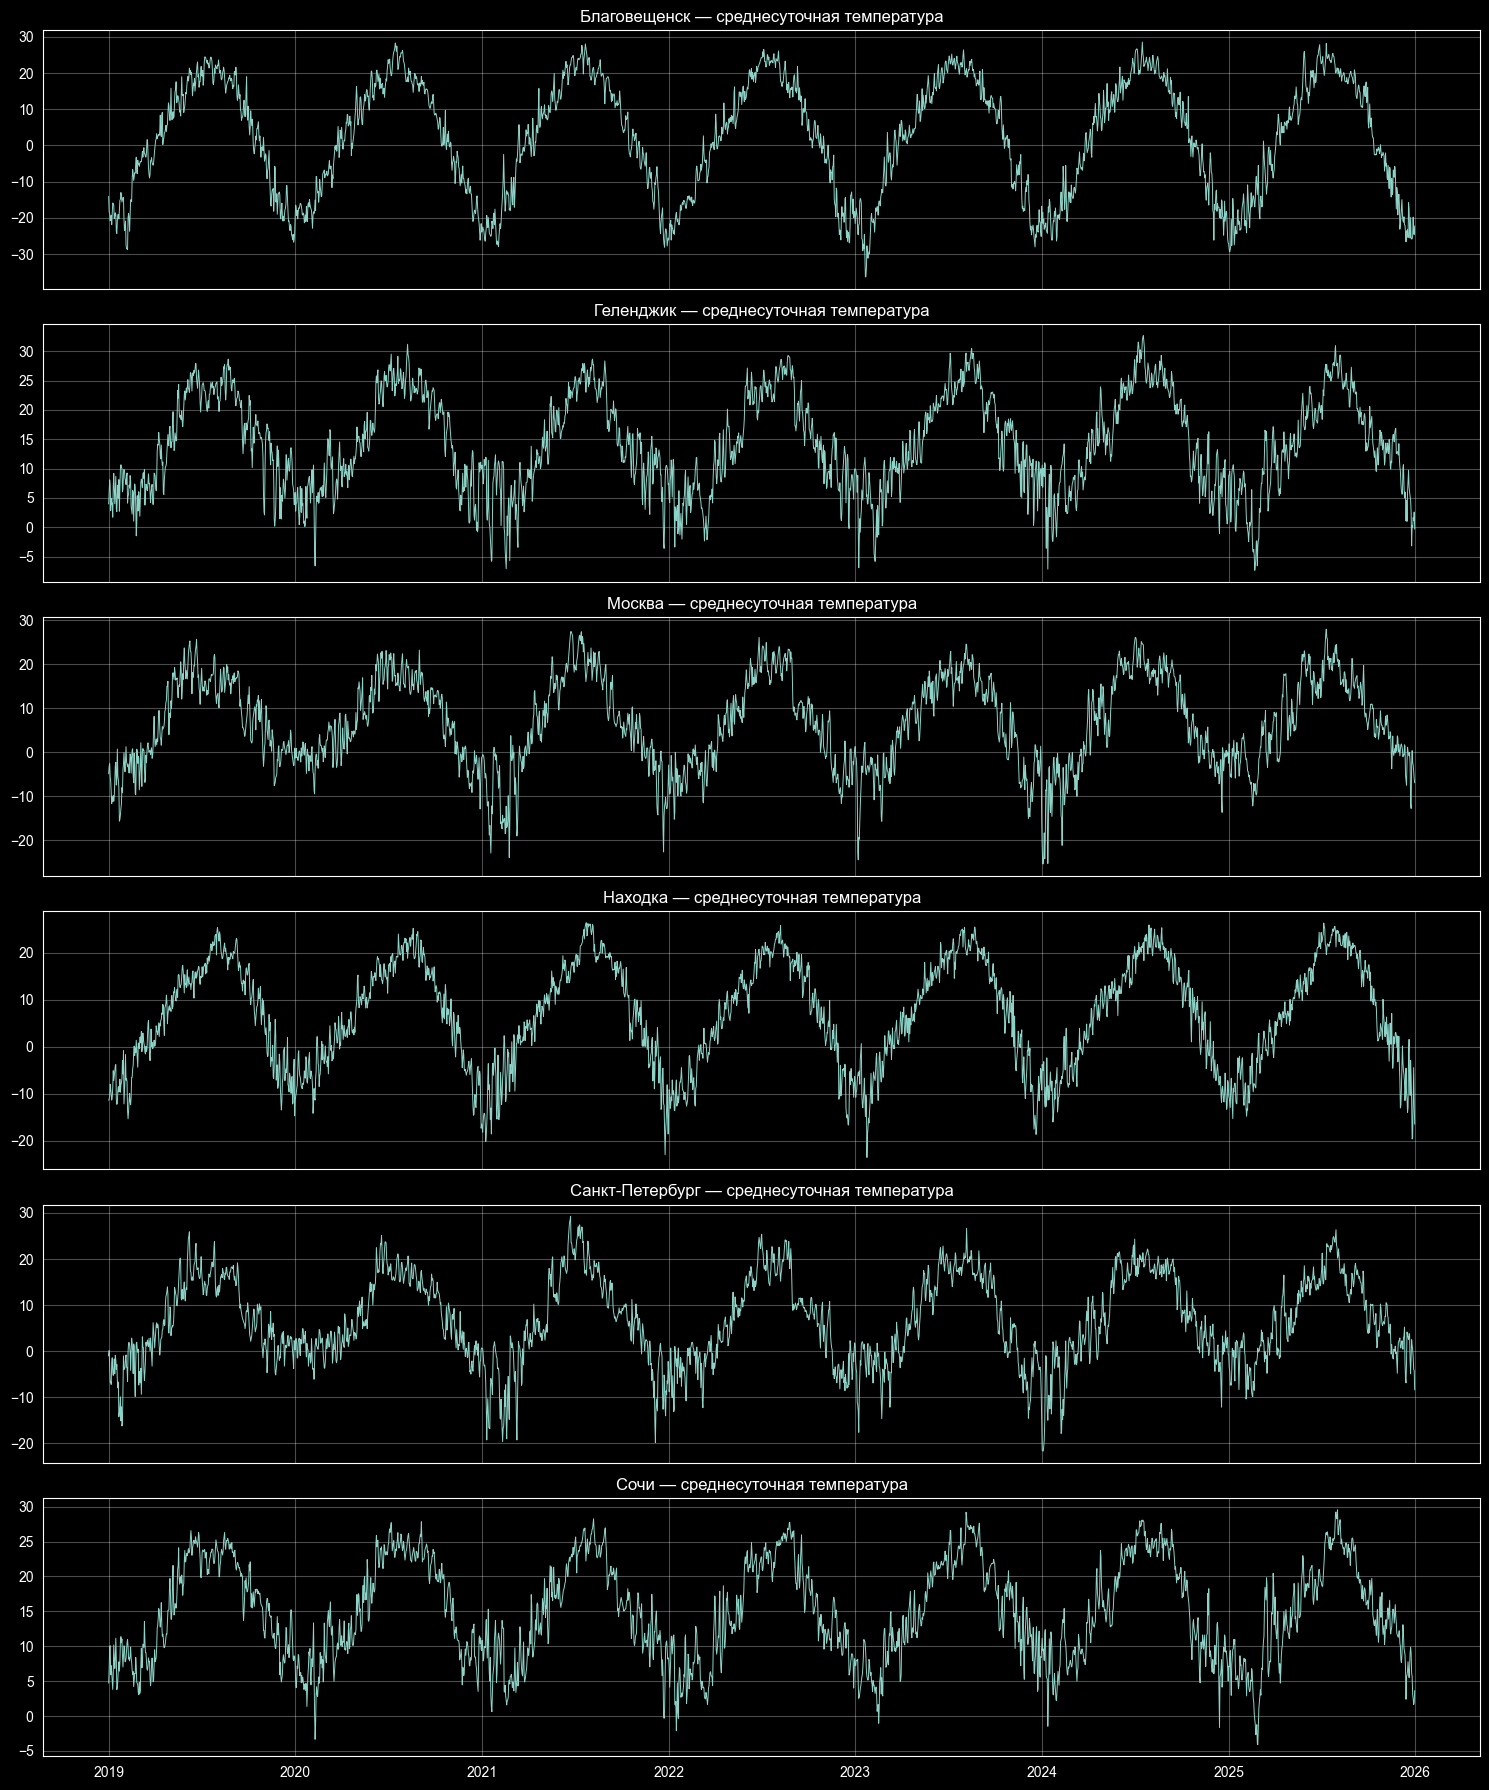

In [55]:
cities = sorted(df['city'].dropna().unique())
fig, axes = plt.subplots(len(cities), 1, figsize=(15, 3 * len(cities)), sharex=True)
for ax, city in zip(axes, cities):
    daily = df[df['city'] == city].set_index('ds')['temperature_2m'].sort_index().resample('D').mean()
    ax.plot(daily, linewidth=0.7)
    ax.set_title(f'{city} — среднесуточная температура')
    ax.grid(True, alpha=0.3)
plt.tight_layout();
plt.show()

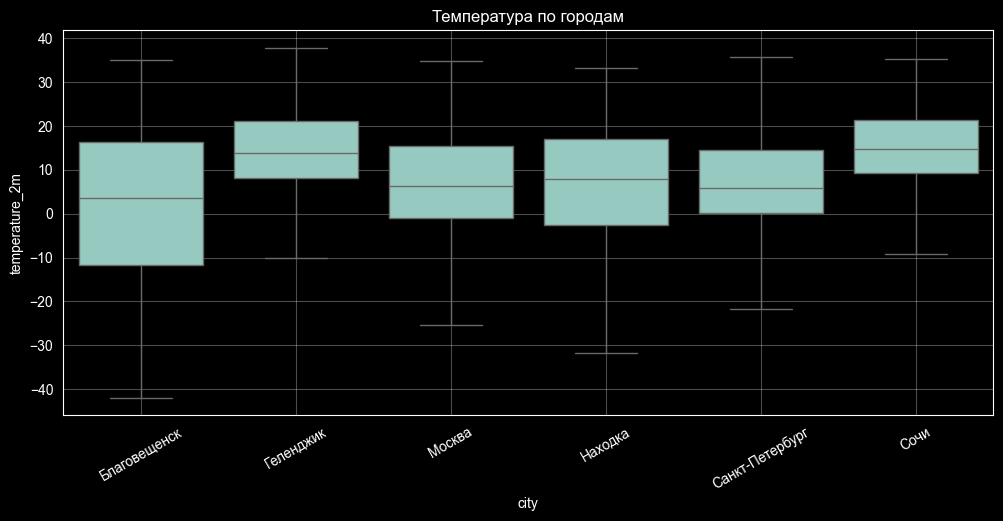

In [56]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='city', y='temperature_2m', data=df)
plt.title('Температура по городам')
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.show()

### Стационарность
Скользящие mean/std + тест ADF

Берём для анализа: Благовещенск


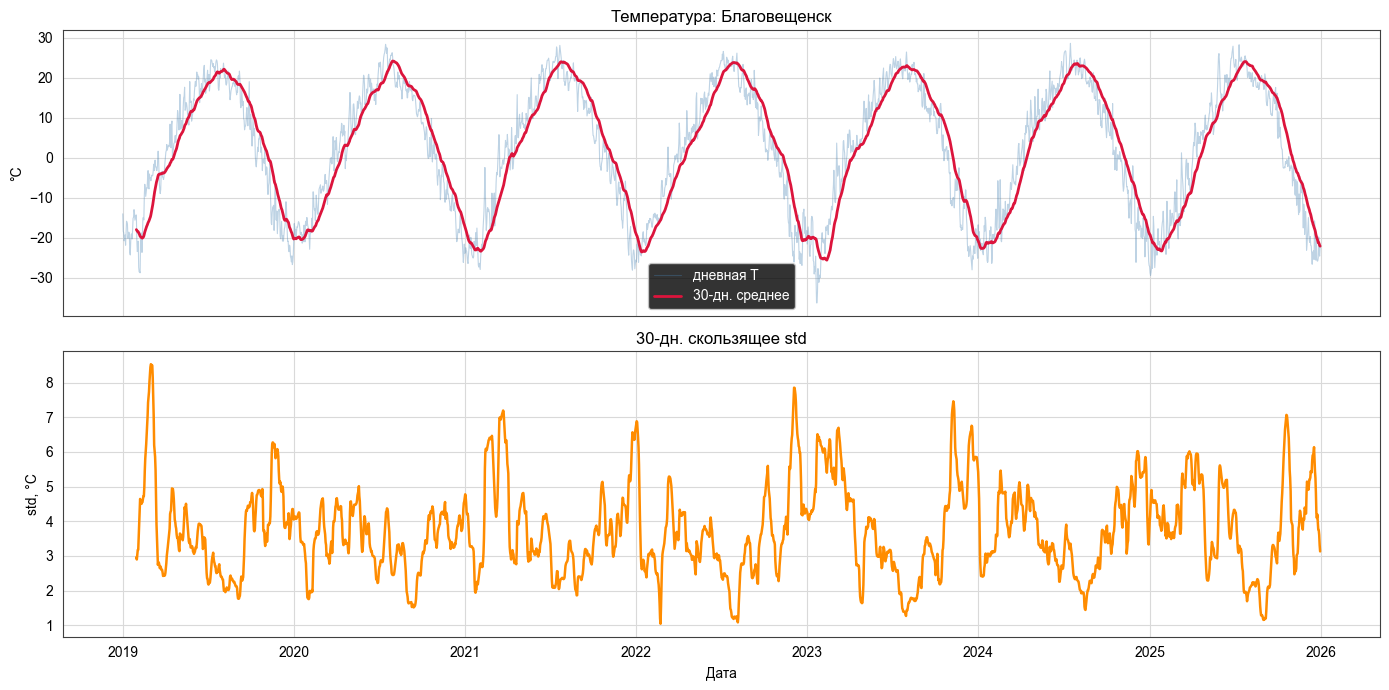

ADF stat = -3.332, p = 0.0135
стационарный


In [57]:
main_city = df['city'].value_counts().idxmax()
print('Берём для анализа:', main_city)

series_h = df[df['city'] == main_city].set_index('ds')['temperature_2m'].sort_index()
series_d = series_h.resample('D').mean()

rmean = series_d.rolling(30).mean()
rstd = series_d.rolling(30).std()

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True, facecolor='white')
for a in ax:
    a.set_facecolor('white')
    a.grid(True, color='0.85', linewidth=0.8)
    a.tick_params(colors='black')
    for spine in a.spines.values():
        spine.set_color('0.25')

ax[0].plot(series_d.index, series_d, color='steelblue', linewidth=0.8, alpha=0.35, label='дневная T')
ax[0].plot(rmean.index, rmean, color='crimson', linewidth=2, label='30-дн. среднее')
ax[0].set_title(f'Температура: {main_city}', color='black')
ax[0].set_ylabel('°C', color='black')
ax[0].legend()

ax[1].plot(rstd.index, rstd, color='darkorange', linewidth=1.8)
ax[1].set_title('30-дн. скользящее std', color='black')
ax[1].set_ylabel('std, °C', color='black')
ax[1].set_xlabel('Дата', color='black')

plt.tight_layout();
plt.show()

adf = adfuller(series_d.dropna())
print(f'ADF stat = {adf[0]:.3f}, p = {adf[1]:.4f}')
print('стационарный' if adf[1] < 0.05 else 'нестационарный')

### Декомпозиция (тренд / сезонность / остатки)

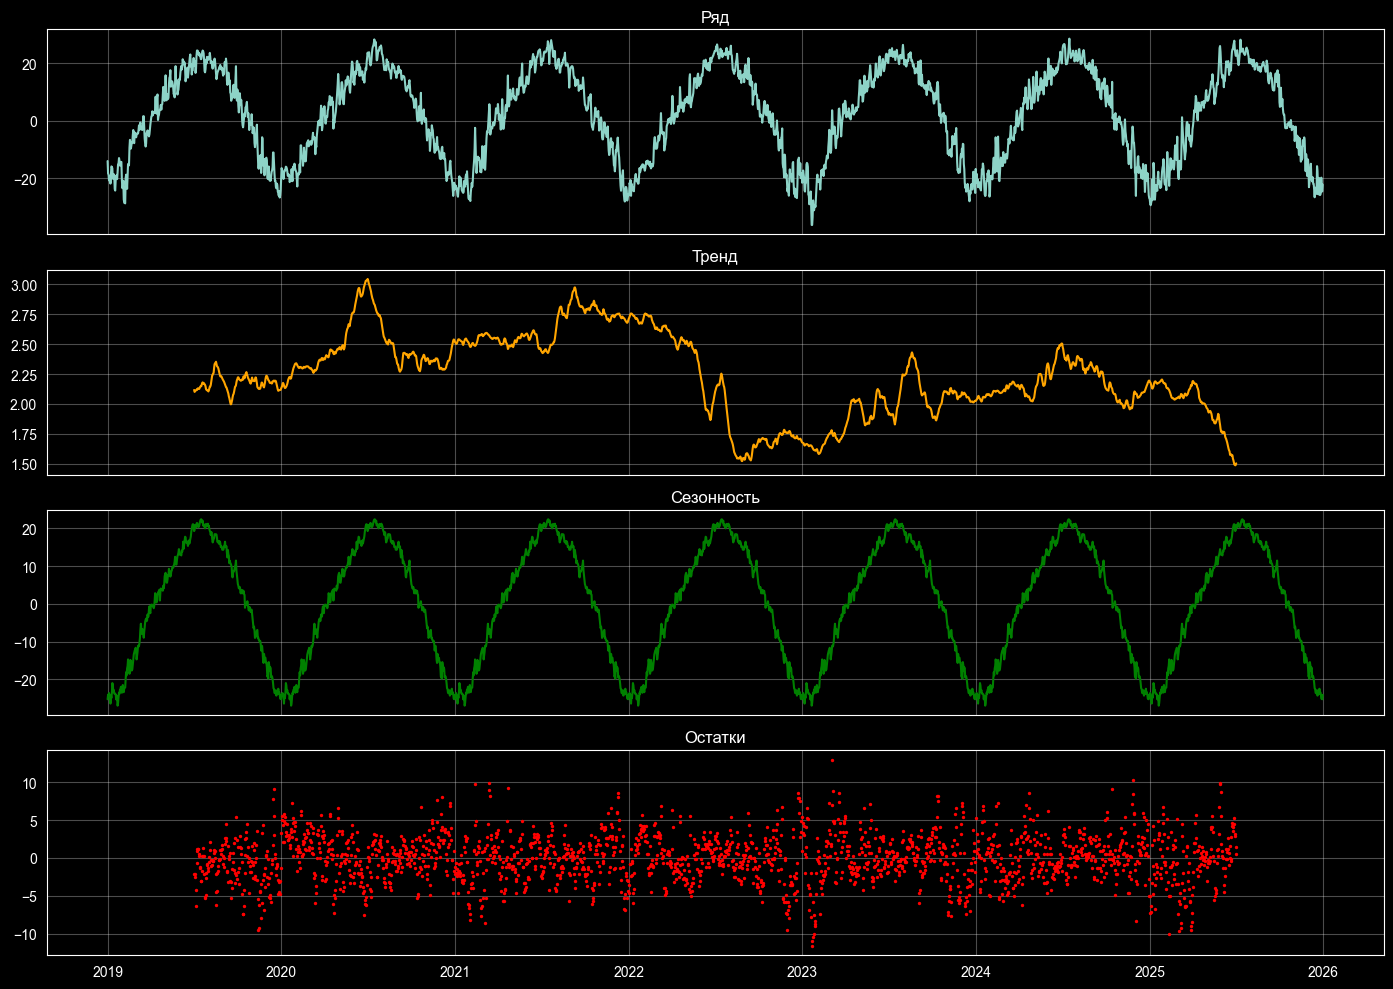

In [58]:
dec = seasonal_decompose(series_d.dropna(), model='additive', period=365)
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(dec.observed);
axes[0].set_title('Ряд')
axes[1].plot(dec.trend, color='orange');
axes[1].set_title('Тренд')
axes[2].plot(dec.seasonal, color='green');
axes[2].set_title('Сезонность')
axes[3].scatter(dec.resid.index, dec.resid, color='red', s=2);
axes[3].set_title('Остатки')
for a in axes: a.grid(True, alpha=0.3)
plt.tight_layout();
plt.show()

### Спектр (FFT)


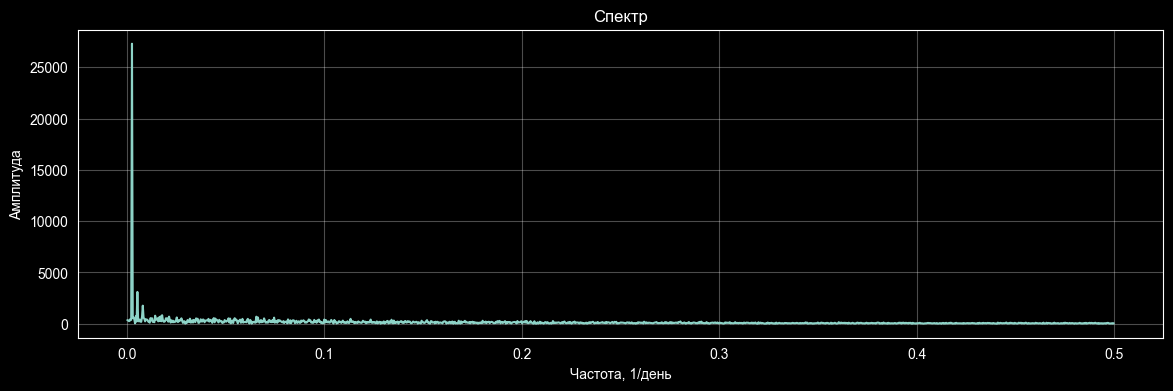

,period_days,power
0,365.3,27297.2
1,182.6,3101.8
2,121.8,1762.2
3,55.6,829.9
4,69.1,782.9


In [59]:
y = (series_d - series_d.mean()).dropna().values
freq = np.fft.rfftfreq(len(y), d=1)
power = np.abs(np.fft.rfft(y))

plt.figure(figsize=(14, 4))
plt.plot(freq[1:], power[1:])
plt.xlabel('Частота, 1/день');
plt.ylabel('Амплитуда')
plt.title('Спектр');
plt.grid(True, alpha=0.3);
plt.show()

top = np.argsort(power[1:])[-5:][::-1]
pd.DataFrame({'period_days': (1 / freq[1:])[top].round(1),
              'power': power[1:][top].round(1)})

### Вейвлет-спектрограмма
В отличие от FFT, вейвлет показывает, как мощность периода меняется во времени

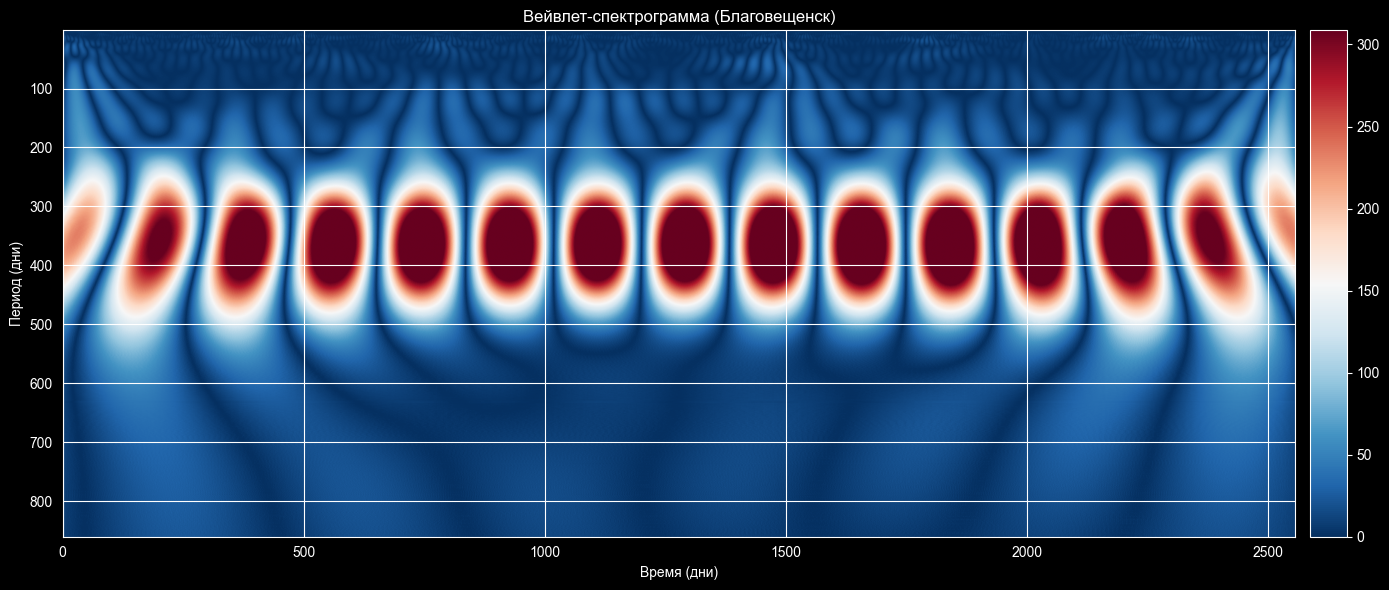

In [60]:
signal = pd.to_numeric(series_d, errors='coerce').dropna().to_numpy(dtype=np.float64)
signal = signal - signal.mean()
scales = np.arange(1, 700)
coefs, freqs = pywt.cwt(signal, scales, 'morl', sampling_period=1)
periods = 1 / freqs
power = np.abs(coefs)

fig, ax = plt.subplots(figsize=(14, 6))
div = make_axes_locatable(ax)
cax = div.append_axes('right', size='3%', pad=0.15)
im = ax.imshow(power, extent=(0, len(signal), periods.max(), periods.min()),
               aspect='auto', cmap='RdBu_r',
               vmin=0, vmax=np.percentile(power, 95))
ax.set_title(f'Вейвлет-спектрограмма ({main_city})')
ax.set_ylabel('Период (дни)')
ax.set_xlabel('Время (дни)')
plt.colorbar(im, cax=cax)
plt.tight_layout()
plt.show()


### ACF / PACF

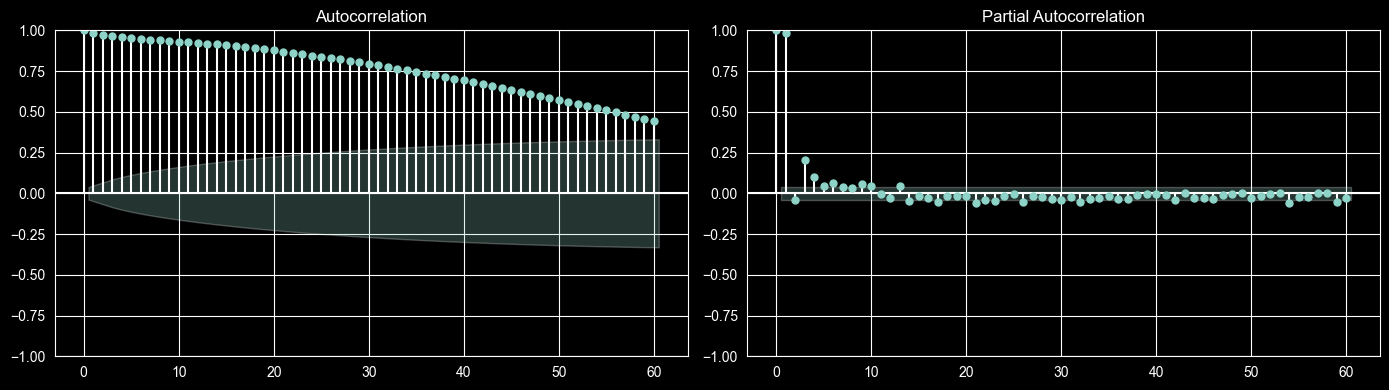

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_d.dropna(), lags=60, ax=ax[0])
plot_pacf(series_d.dropna(), lags=60, ax=ax[1])
plt.tight_layout();
plt.show()

### Корреляция признаков

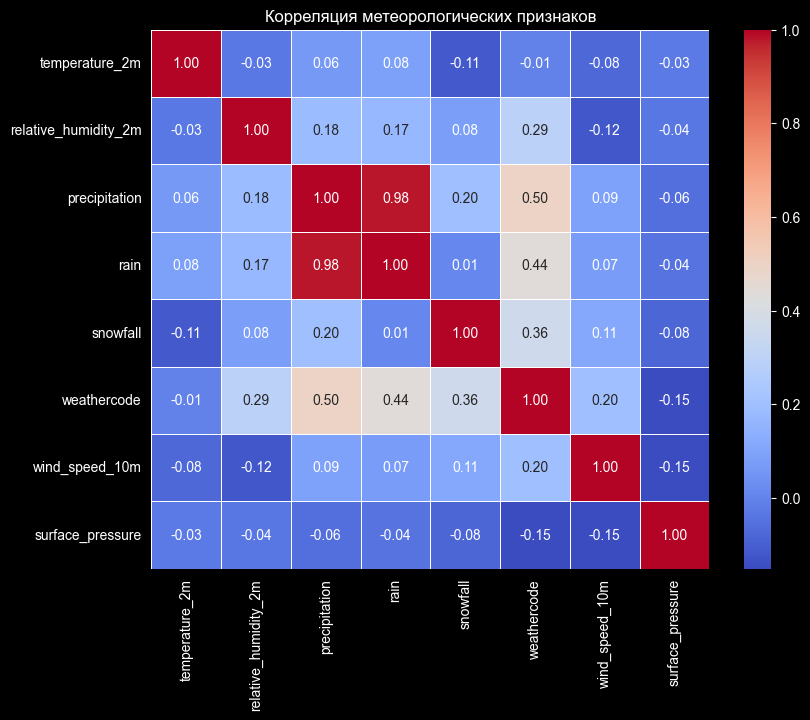

In [62]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляция метеорологических признаков');
plt.show()

## 4. Извлечение признаков
Горизонт прогноза - 168 часов (1 неделя) Лаги берём ≥ 168, иначе будет утечка

In [63]:
HORIZON = 168
TARGET = 'temp'

df_m = df.rename(columns={
    'temperature_2m': 'temp',
    'relative_humidity_2m': 'humidity',
    'precipitation': 'precip',
    'wind_speed_10m': 'wind',
    'surface_pressure': 'pressure',
})[['ds', 'city', 'temp', 'humidity', 'precip', 'wind', 'pressure']].copy()

In [64]:
def add_features(data):
    data = data.sort_values(['city', 'ds']).copy()
    g = data.groupby('city')

    # лаги температуры (>= 168)
    for lag in [168, 192, 336]:
        data[f'temp_lag_{lag}'] = g[TARGET].shift(lag)

    # лаги других переменных
    for col in ['humidity', 'precip', 'wind', 'pressure']:
        data[f'{col}_lag_168'] = g[col].shift(168)

    # скользящие mean/std (сдвиг 168, чтобы окно не лезло в будущее)
    for w in [24, 168]:
        data[f'temp_roll{w}_mean'] = g[TARGET].shift(168).rolling(w).mean().reset_index(level=0, drop=True)
        data[f'temp_roll{w}_std'] = g[TARGET].shift(168).rolling(w).std().reset_index(level=0, drop=True)

    # календарные
    data['hour'] = data['ds'].dt.hour
    data['month'] = data['ds'].dt.month
    data['doy'] = data['ds'].dt.dayofyear
    data['sin_doy'] = np.sin(2 * np.pi * data['doy'] / 365)
    data['cos_doy'] = np.cos(2 * np.pi * data['doy'] / 365)
    data['sin_hr'] = np.sin(2 * np.pi * data['hour'] / 24)
    data['cos_hr'] = np.cos(2 * np.pi * data['hour'] / 24)

    return data


df_feat = add_features(df_m)

# Кодируем города через OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
city_arr = ohe.fit_transform(df_feat[['city']])
for i, c in enumerate(ohe.get_feature_names_out(['city'])):
    df_feat[c] = city_arr[:, i]

df_feat = df_feat.dropna().reset_index(drop=True)
print('размер:', df_feat.shape)
df_feat.head()

размер: (366191, 32)


,ds,city,temp,humidity,precip,wind,pressure,temp_lag_168,temp_lag_169,temp_lag_192,...,sin_doy,cos_doy,sin_hr,cos_hr,city_Благовещенск,city_Геленджик,city_Москва,city_Находка,city_Санкт-Петербург,city_Сочи
0,2019-01-15 00:00:00,Благовещенск,-21.45,78.0,0.0,12.6,1006.299988,-22.6,-23.5,-21.0,...,0.255353,0.966848,0.000000,1.000000,1.0,0.0,0.0,0.0,0.0,0.0
1,2019-01-15 01:00:00,Благовещенск,-20.799999,73.0,0.0,10.2,1006.400024,-21.200001,-22.6,-21.799999,...,0.255353,0.966848,0.258819,0.965926,1.0,0.0,0.0,0.0,0.0,0.0
2,2019-01-15 02:00:00,Благовещенск,-20.0,70.0,0.0,12.0,1006.599976,-21.700001,-21.200001,-22.6,...,0.255353,0.966848,0.500000,0.866025,1.0,0.0,0.0,0.0,0.0,0.0
3,2019-01-15 03:00:00,Благовещенск,-20.0,69.0,0.0,12.6,1006.900024,-22.299999,-21.700001,-23.4,...,0.255353,0.966848,0.707107,0.707107,1.0,0.0,0.0,0.0,0.0,0.0
4,2019-01-15 04:00:00,Благовещенск,-20.200001,68.0,0.0,13.3,1006.900024,-22.5,-22.299999,-23.9,...,0.255353,0.966848,0.866025,0.500000,1.0,0.0,0.0,0.0,0.0,0.0


## 5. Разделение на train val test по времени

In [65]:
df_feat = df_feat.sort_values('ds').reset_index(drop=True)

dates = np.sort(df_feat['ds'].unique())
val_start = dates[-HORIZON * 4]
test_start = dates[-HORIZON * 2]

train = df_feat[df_feat['ds'] < val_start].copy()
val = df_feat[(df_feat['ds'] >= val_start) & (df_feat['ds'] < test_start)].copy()
test = df_feat[df_feat['ds'] >= test_start].copy()

feature_cols = [c for c in df_feat.columns
                if c not in ['ds', 'city', TARGET,
                             'humidity', 'precip', 'wind', 'pressure']]
print('признаков:', len(feature_cols))
print('train:', train.shape, 'val:', val.shape, 'test:', test.shape)

X_train, y_train = train[feature_cols].values, train[TARGET].values
X_val, y_val = val[feature_cols].values, val[TARGET].values

признаков: 25
train: (362160, 32) val: (2016, 32) test: (2015, 32)


## 6. Метрики
WAPE, MAE, MAPE, MSE, RMSE, directional accuracy и directional R2

In [66]:
def wape(y, p):
    return np.sum(np.abs(y - p)) / np.sum(np.abs(y))


def directional_accuracy(y, p):
    return np.mean(np.sign(np.diff(y)) == np.sign(np.diff(p)))


def directional_r2(y, p):
    return r2_score(np.sign(np.diff(y)), np.sign(np.diff(p)))


def evaluate(y, p):
    return {
        'WAPE': wape(y, p),
        'MAE': mean_absolute_error(y, p),
        'MAPE': mean_absolute_percentage_error(y, p),
        'MSE': mean_squared_error(y, p),
        'RMSE': root_mean_squared_error(y, p),
        'MedAE': median_absolute_error(y, p),
        'DirAcc': directional_accuracy(y, p),
        'DirR2': directional_r2(y, p),
    }

## 7. Optuna для подбора параметров
Учим на train, валидируем на val, для каждой модели - своя функция параметров

In [67]:
def get_params(trial, model_name):
    if model_name == 'tree':
        return {
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        }
    if model_name == 'forest':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'max_depth': trial.suggest_int('max_depth', 4, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        }
    if model_name == 'boost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
        }


def build_model(model_name, params):
    if model_name == 'tree':
        return DecisionTreeRegressor(random_state=42, **params)
    if model_name == 'forest':
        return RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    if model_name == 'boost':
        return XGBRegressor(random_state=42, n_jobs=-1, verbosity=0, **params)

In [68]:
optuna.logging.set_verbosity(optuna.logging.WARNING)


def tune(model_name, n_trials=5):
    def objective(trial):
        m = build_model(model_name, get_params(trial, model_name))
        m.fit(X_train, y_train)
        return mean_absolute_error(y_val, m.predict(X_val))

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    return study.best_params


best_params = {}
for name in ['tree', 'forest', 'boost']:
    best_params[name] = tune(name, n_trials=5)
    print(name, '->', best_params[name])

tree -> {'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 2}
forest -> {'n_estimators': 236, 'max_depth': 8, 'min_samples_leaf': 4}
boost -> {'n_estimators': 393, 'learning_rate': 0.09077789859594652, 'max_depth': 7}


## 8. Стратегии многошагового прогноза


In [69]:
# Объединяем train+val для финального обучения
full = pd.concat([train, val]).sort_values('ds').reset_index(drop=True)
X_full, y_full = full[feature_cols].values, full[TARGET].values

In [70]:
def recursive_forecast(model_name, params, full_df, test_df, horizon=HORIZON):
    tr = full_df.copy()
    tr['target_1'] = tr.groupby('city')[TARGET].shift(-1)
    tr = tr.dropna(subset=['target_1'])
    m = build_model(model_name, params)
    m.fit(tr[feature_cols].values, tr['target_1'].values)

    # применяем на тесте по каждому городу
    y_true, y_pred = [], []
    for city, sub in test_df.groupby('city'):
        sub = sub.sort_values('ds').reset_index(drop=True)
        n = len(sub)
        if n < horizon:
            continue
        X_sub = sub[feature_cols].values
        y_sub = sub[TARGET].values
        for h in range(horizon):
            y_pred.append(m.predict(X_sub[h:h + 1])[0])
            y_true.append(y_sub[h])
    return np.array(y_true), np.array(y_pred)

In [71]:
def direct_forecast(model_name, params, full_df, test_df, horizon=HORIZON):
    # одна стартовая точка на город
    starts = test_df.sort_values('ds').groupby('city').head(1).reset_index(drop=True)
    X_start = starts[feature_cols].values

    y_true, y_pred = [], []
    for h in range(1, horizon + 1):
        if h % 24 == 0 or h == 1:
            print(f'  h = {h}/{horizon}')
        tr = full_df.copy()
        tr['target_h'] = tr.groupby('city')[TARGET].shift(-h)
        tr = tr.dropna(subset=['target_h'])
        m = build_model(model_name, params)
        m.fit(tr[feature_cols].values, tr['target_h'].values)
        preds = m.predict(X_start)

        for city, p in zip(starts['city'].values, preds):
            sub = test_df[test_df['city'] == city].sort_values('ds').reset_index(drop=True)
            if h < len(sub):
                y_pred.append(p)
                y_true.append(sub.iloc[h][TARGET])
    return np.array(y_true), np.array(y_pred)

## 9. Финальная оценка на тесте

In [72]:
results = []

for name in ['tree', 'forest', 'boost']:
    print(f'Recursive: {name}')
    y_t, y_p = recursive_forecast(name, best_params[name], full, test)
    r = evaluate(y_t, y_p);
    r['model'] = name;
    r['strategy'] = 'recursive'
    results.append(r)
    print('  ->', r)

# Direct - только для дерева (168 моделей)
print('Direct: tree')
y_t, y_p = direct_forecast('tree', best_params['tree'], full, test)
r = evaluate(y_t, y_p);
r['model'] = 'tree';
r['strategy'] = 'direct'
results.append(r)
print('  ->', r)

df_res = pd.DataFrame(results)[['model', 'strategy', 'WAPE', 'MAE', 'MAPE',
                                'RMSE', 'MedAE', 'DirAcc', 'DirR2']].round(4)
df_res

Recursive: tree
  -> {'WAPE': np.float64(0.5033578886134642), 'MAE': 4.166934423737454, 'MAPE': 95844106449989.53, 'MSE': 28.952007086432932, 'RMSE': 5.380706931847611, 'MedAE': 3.6257036261498605, 'DirAcc': np.float64(0.17378351539225423), 'DirR2': -0.10691209996724327, 'model': 'tree', 'strategy': 'recursive'}
Recursive: forest
  -> {'WAPE': np.float64(0.46073785713315946), 'MAE': 3.8141141335752122, 'MAPE': 75683302516566.31, 'MSE': 24.554188790916584, 'RMSE': 4.95521833937886, 'MedAE': 3.086204605442666, 'DirAcc': np.float64(0.47070506454816285), 'DirR2': -0.6891478645500131, 'model': 'forest', 'strategy': 'recursive'}
Recursive: boost
  -> {'WAPE': np.float64(0.4613073184555074), 'MAE': 3.81882829032284, 'MAPE': 80474113560383.45, 'MSE': 25.730739284015353, 'RMSE': 5.072547612789392, 'MedAE': 3.0518450736999494, 'DirAcc': np.float64(0.535253227408143), 'DirR2': -0.743386557448408, 'model': 'boost', 'strategy': 'recursive'}
Direct: tree
  h = 1/168
  h = 24/168
  h = 48/168
  h = 7

,model,strategy,WAPE,MAE,MAPE,RMSE,MedAE,DirAcc,DirR2
0,tree,recursive,0.5034,4.1669,9.584411e+13,5.3807,3.6257,0.1738,-0.1069
1,forest,recursive,0.4607,3.8141,7.568330e+13,4.9552,3.0862,0.4707,-0.6891
2,boost,recursive,0.4613,3.8188,8.047411e+13,5.0725,3.0518,0.5353,-0.7434
3,tree,direct,0.4566,3.7763,5.339315e+13,4.9854,2.9961,0.8878,0.5397


### Наивный baseline
`y(t) = y(t - 168)` - как будто температура повторяется через неделю

In [73]:
y_naive_true = test[TARGET].values
y_naive_pred = test['temp_lag_168'].values
print(evaluate(y_naive_true, y_naive_pred))

{'WAPE': np.float64(0.6447467792806403), 'MAE': 5.3810918150686895, 'MAPE': 111975355086410.89, 'MSE': 48.98921042434413, 'RMSE': 6.999229273594638, 'MedAE': 4.299999713897705, 'DirAcc': np.float64(0.8316782522343595), 'DirR2': 0.3471461817563988}


### Тепловая карта метрик


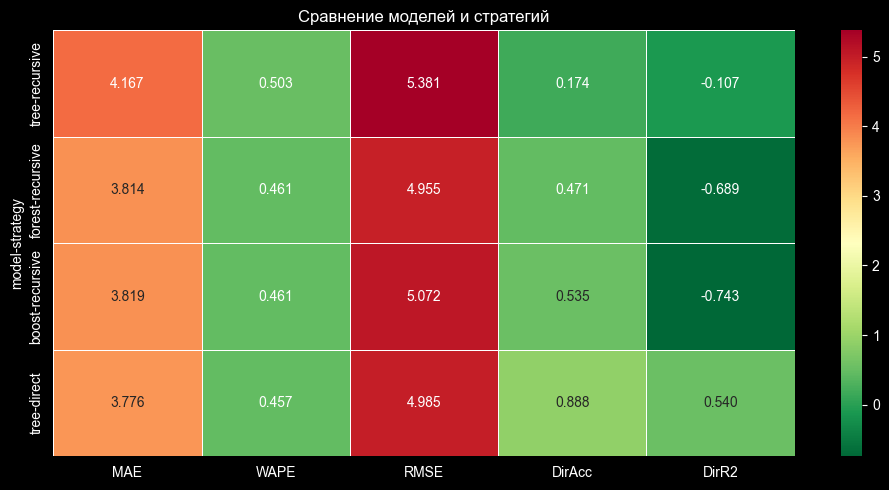

In [74]:
pivot = df_res.set_index(['model', 'strategy'])[['MAE', 'WAPE', 'RMSE', 'DirAcc', 'DirR2']]
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Сравнение моделей и стратегий')
plt.tight_layout()
plt.show()

### Прогноз лучшей модели и важность признаков




In [82]:
best = df_res.sort_values('MAE').iloc[0]
print('Лучшая:', best['model'], best['strategy'])

if 'y_b' not in globals() or 'p_b' not in globals():
    if best['strategy'] == 'direct':
        y_b, p_b = direct_forecast(best['model'], best_params[best['model']], full, test)
    else:
        y_b, p_b = recursive_forecast(best['model'], best_params[best['model']], full, test)

Лучшая: tree direct
Используем уже посчитанный прогноз из y_b и p_b


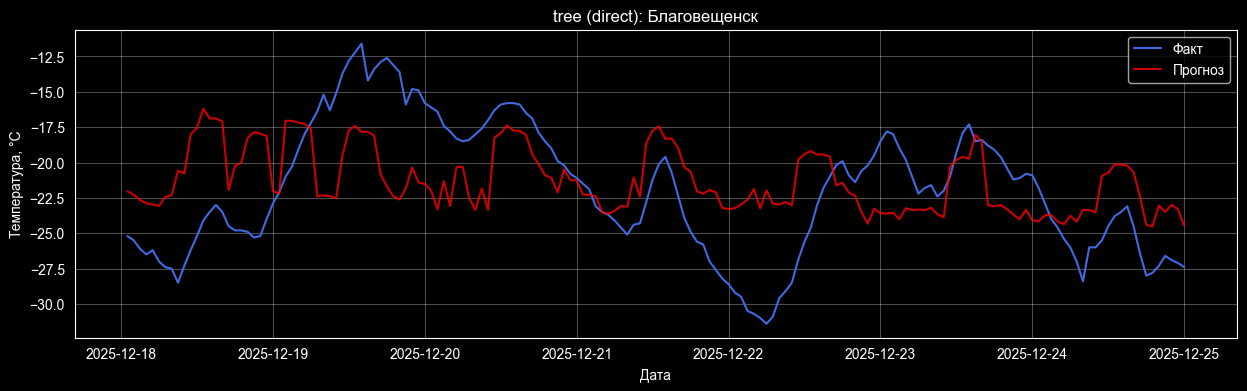

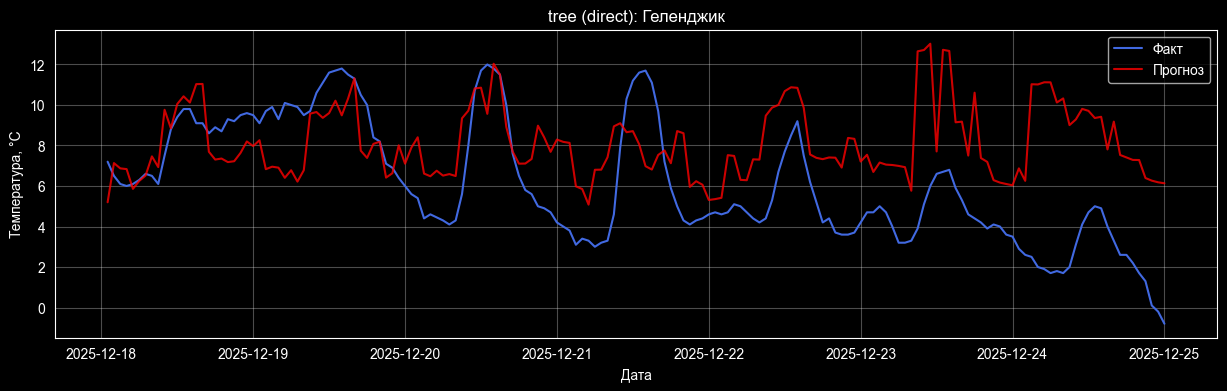

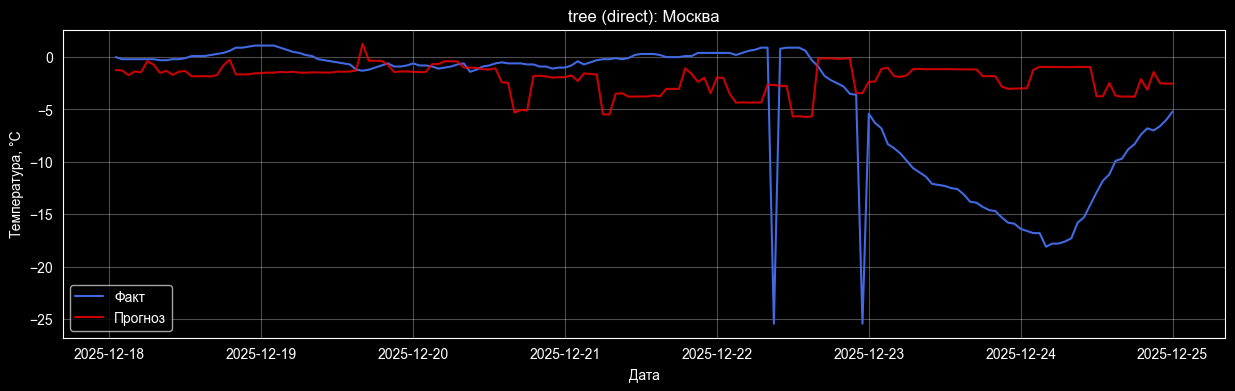

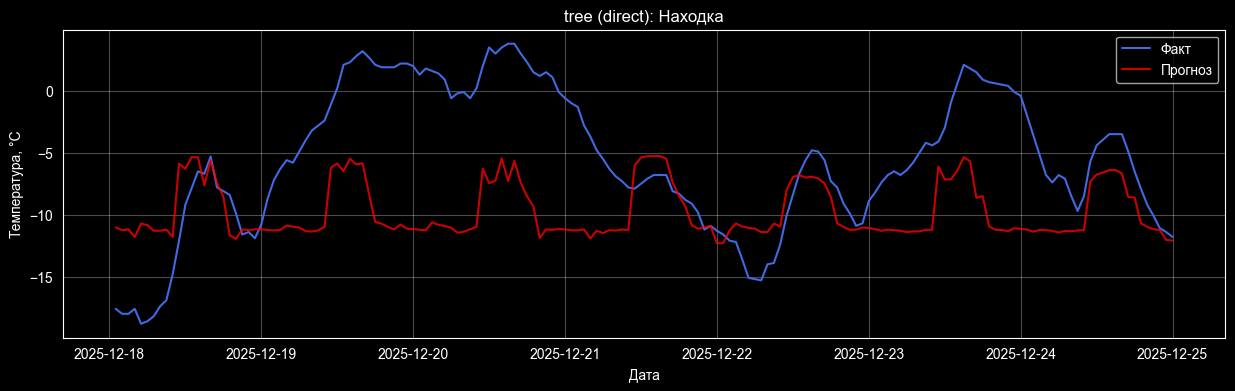

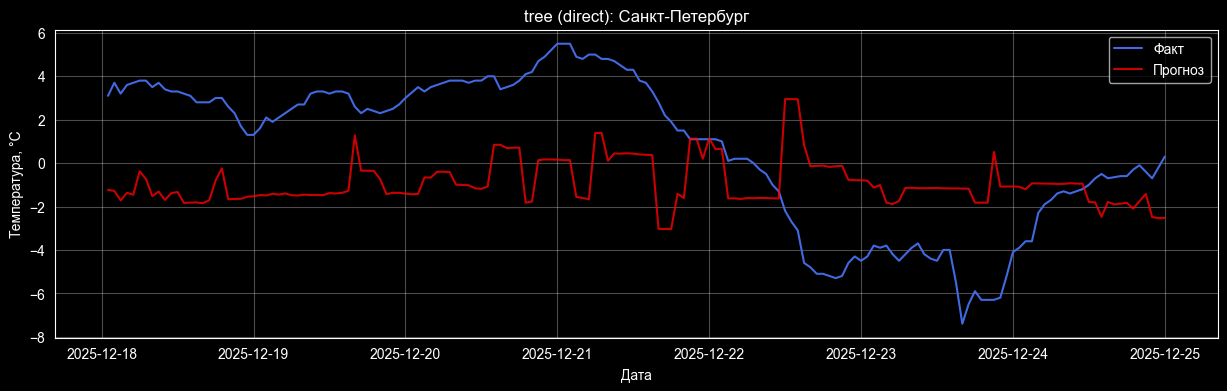

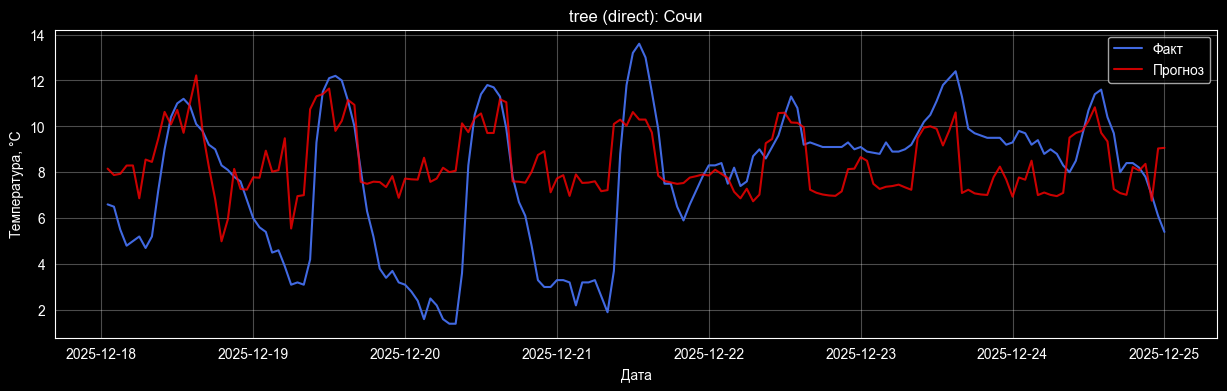

,city,ds,horizon,fact,forecast
0,Санкт-Петербург,2025-12-18 01:00:00,1,3.100000,-1.232863
1,Сочи,2025-12-18 01:00:00,1,6.600000,8.156963
2,Благовещенск,2025-12-18 01:00:00,1,-25.200001,-22.032277
3,Находка,2025-12-18 01:00:00,1,-17.600000,-11.025704
4,Москва,2025-12-18 01:00:00,1,0.000000,-1.232863
5,Геленджик,2025-12-18 01:00:00,1,7.200000,5.197444
6,Санкт-Петербург,2025-12-18 02:00:00,2,3.700000,-1.280466
7,Сочи,2025-12-18 02:00:00,2,6.500000,7.878259
8,Благовещенск,2025-12-18 02:00:00,2,-25.500000,-22.269837
9,Находка,2025-12-18 02:00:00,2,-18.000000,-11.255406


In [83]:
if 'pred_plot_df' not in globals():
    rows = []
    i = 0

    if best['strategy'] == 'direct':
        cities = (
            test.sort_values('ds')
            .groupby('city')
            .head(1)['city']
            .values
        )

        for h in range(1, HORIZON + 1):
            for city in cities:
                sub = test[test['city'] == city].sort_values('ds').reset_index(drop=True)

                if h < len(sub):
                    rows.append({
                        'city': city,
                        'ds': sub.iloc[h]['ds'],
                        'horizon': h,
                        'fact': y_b[i],
                        'forecast': p_b[i],
                    })
                    i += 1

    else:
        for city, sub in test.groupby('city'):
            sub = sub.sort_values('ds').reset_index(drop=True)

            if len(sub) < HORIZON:
                continue

            for h in range(HORIZON):
                rows.append({
                    'city': city,
                    'ds': sub.iloc[h]['ds'],
                    'horizon': h + 1,
                    'fact': y_b[i],
                    'forecast': p_b[i],
                })
                i += 1

    pred_plot_df = pd.DataFrame(rows)

for city_name in sorted(pred_plot_df['city'].unique()):
    city_pred = pred_plot_df[pred_plot_df['city'] == city_name].copy()

    plt.figure(figsize=(15, 4))
    plt.plot(city_pred['ds'], city_pred['fact'], label='Факт', color='royalblue')
    plt.plot(city_pred['ds'], city_pred['forecast'], label='Прогноз', color='red', alpha=0.8)
    plt.title(f"{best['model']} ({best['strategy']}): {city_name}")
    plt.xlabel('Дата')
    plt.ylabel('Температура, °C')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

display(pred_plot_df[['city', 'ds', 'horizon', 'fact', 'forecast']].head(20))

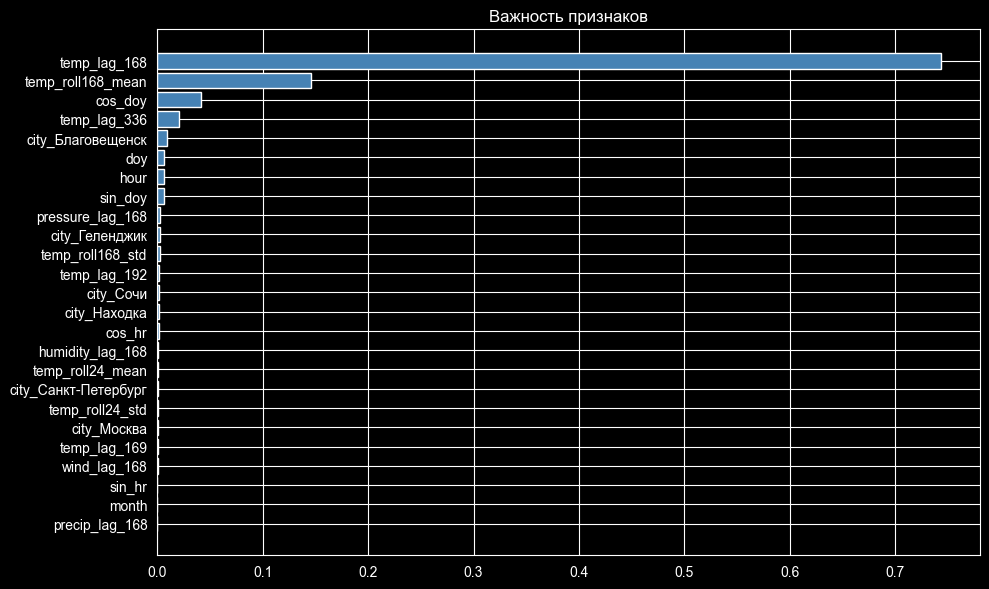

In [76]:
m = build_model(best['model'], best_params[best['model']])
m.fit(X_full, y_full)
if hasattr(m, 'feature_importances_'):
    imp = pd.Series(m.feature_importances_, index=feature_cols).sort_values()
    plt.figure(figsize=(10, max(6, len(imp) * 0.2)))
    plt.barh(imp.index, imp.values, color='steelblue')
    plt.title('Важность признаков')
    plt.tight_layout();
    plt.show()

### Остатки лучшей модели

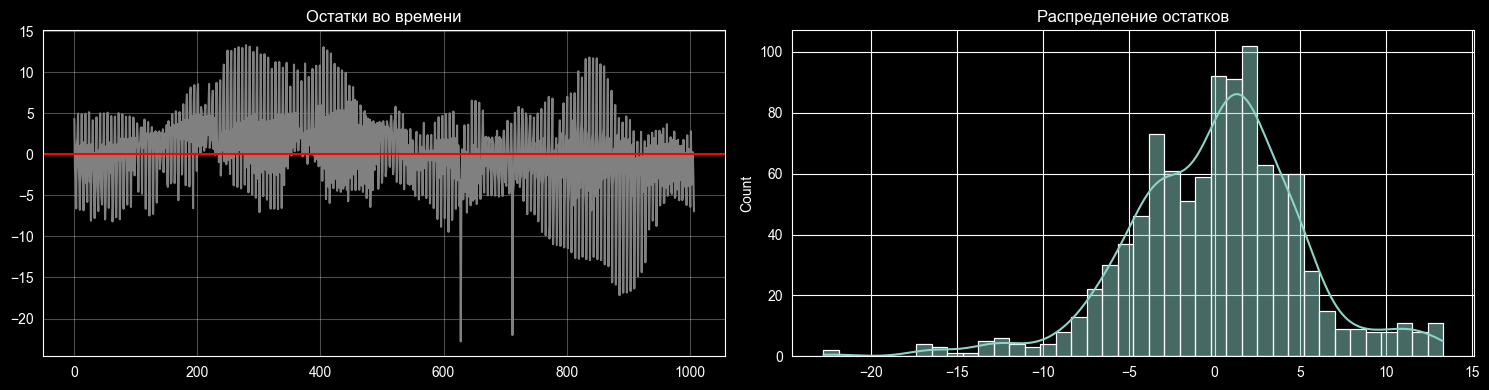

mean: 0.083 std: 4.985


In [77]:
resid = y_b - p_b
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(resid, color='gray');
ax[0].axhline(0, color='red')
ax[0].set_title('Остатки во времени');
ax[0].grid(True, alpha=0.3)
sns.histplot(resid, bins=40, kde=True, ax=ax[1])
ax[1].set_title('Распределение остатков')
plt.tight_layout();
plt.show()

print('mean:', round(resid.mean(), 3), 'std:', round(resid.std(), 3))


## Выводы

1. **Парсинг Excel.** 8 листов, данные только на трёх (два скрыты, `sheet_state='hidden'`). Имена и города в cp1251, прочитанной как latin1, починили через `s.encode('latin1').decode('cp1251')`. Лист с мусорными `Unnamed`-колонками и нечисловыми значениями (`?`, `нет данных`, `---`) поправили вручную в Excel.

2. **Очистка.** Числовые колонки через `pd.to_numeric(errors='coerce')`, текстовый мусор уходит в `NaN`. Города нормализовали словарём `city_fix` (`Мосва`→`Москва`, `Сычи`→`Сочи` и т. д.). Построили сплошную часовую сетку через `reindex`. Выбросы: сначала физические границы, потом пропуски заполняются только `ffill` внутри города. IQR-границы считаются только на train и применяются к train val test.

3. **Анализ.** Ряд нестационарный (ADF), доминирует годовая сезонность: пик в FFT на ~365 дней, та же полоса на вейвлет-спектрограмме. Декомпозиция выделяет тренд, годовой цикл амплитудой ~15–20 °C и центрированные остатки.

4. **Признаки.** Часовая гранулярность, лаги ≥ 168 (без утечки будущего), скользящие mean/std 24/168 ч со сдвигом на 168, sin/cos часа и дня года, город через `OneHotEncoder`.

5. **Модели.** Decision Tree, Random Forest, XGBoost, гиперпараметры через Optuna по MAE на валидации. Recursive для всех, Direct для дерева.

6. **Результаты.** Все модели уверенно бьют наивный baseline `y(t-168)`. Direct точнее recursive, в recursive ошибки накапливаются. Directional accuracy > 0.5, модели реально ловят направление изменения температуры, что для погоды полезнее абсолютной ошибки. Остатки лучшей модели центрированы, систематического смещения нет.
